In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Perceptron and Adaline
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.linear_model import SGDClassifier

# Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Support Vector Machines
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from itertools import combinations

In [41]:
def preprocess_data(df, test_size=0.2, random_state=42, return_preprocessor=False, 
                     has_target=True, preprocessor=None, label_encoder=None):
    """
    Comprehensive preprocessing function for the Adult Census dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Raw dataset
    test_size : float, default=0.2
        Proportion of dataset to include in test split (only used if has_target=True)
    random_state : int, default=42
        Random state for reproducibility
    return_preprocessor : bool, default=False
        Whether to return the fitted preprocessor object
    has_target : bool, default=True
        Whether the dataset contains the target variable
    preprocessor : sklearn object, default=None
        Pre-fitted preprocessor to use (for validation data)
    label_encoder : sklearn.preprocessing.LabelEncoder, default=None
        Pre-fitted label encoder (for validation data with target)
    
    Returns:
    --------
    If has_target=True and test_size > 0:
        X_train, X_test, y_train, y_test : arrays
    If has_target=True and test_size=0:
        X_processed, y_encoded : arrays
    If has_target=False:
        X_processed : array
    
    Optional returns if return_preprocessor=True:
        preprocessor, label_encoder
    """
    
    print(f"Original dataset shape: {df.shape}")
    print(f"First 5 rows before transformation:\n{df.head()}\n" + "="*50 + "\n")
    
    # Step 1: Fix column names
    df = df.copy()  # Avoid modifying original dataframe
    
    # Handle unnamed first column
    if df.columns[0] == '' or 'Unnamed' in str(df.columns[0]):
        df = df.rename(columns={df.columns[0]: 'id'})
    
    # Clean column names (remove spaces, special characters)
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
    
    # Step 2: Handle missing values representation
    missing_indicators = ['?', 'unknown', 'Unknown', '', ' ', 'n/a', 'N/A', 'na', 'NA']
    df = df.replace(missing_indicators, np.nan)
    
    print("Missing values by column:")
    missing_summary = df.isnull().sum()
    print(missing_summary[missing_summary > 0])
    print()
    
    # Step 3: Data type corrections
    # Ensure numeric columns are actually numeric
    numeric_columns = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Step 4: Feature Engineering (Basic)
    if 'capital_gain' in df.columns and 'capital_loss' in df.columns:
        df['capital_net'] = df['capital_gain'] - df['capital_loss']
        df['has_capital_gain'] = (df['capital_gain'] > 0).astype(int)
        df['has_capital_loss'] = (df['capital_loss'] > 0).astype(int)
    
    # Age groups
    if 'age' in df.columns:
        df['age_group'] = pd.cut(df['age'], 
                                bins=[0, 25, 35, 45, 55, 65, 100], 
                                labels=['18_25', '26_35', '36_45', '46_55', '56_65', '65_plus'])
    
    # Work hours categories
    if 'hours_per_week' in df.columns:
        df['work_hours_category'] = pd.cut(df['hours_per_week'],
                                          bins=[0, 30, 40, 50, 100],
                                          labels=['part_time', 'full_time', 'overtime', 'excessive'])
    
    # Step 5: Separate features and target
    target_col = 'income'
    
    if has_target:
        if target_col not in df.columns:
            raise ValueError(f"Target column '{target_col}' not found in dataset")
        
        # Remove ID column and target from features
        feature_cols = [col for col in df.columns if col not in ['id', target_col]]
        X = df[feature_cols].copy()
        y = df[target_col].copy()
        
        # Step 6: Encode target variable
        if label_encoder is None:
            le_target = LabelEncoder()
            y_encoded = le_target.fit_transform(y)
            print(f"Target encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
        else:
            le_target = label_encoder
            y_encoded = le_target.transform(y)
        
        print(f"Target distribution: {np.bincount(y_encoded) / len(y_encoded)}")
        print()
    else:
        # No target variable (validation/test data)
        feature_cols = [col for col in df.columns if col != 'id']
        X = df[feature_cols].copy()
        y_encoded = None
        le_target = None
    
    # Step 7: Identify feature types automatically (only if preprocessor not provided)
    if preprocessor is None:
        numeric_features = []
        categorical_features = []
        
        for col in X.columns:
            if X[col].dtype in ['int64', 'float64']:
                # Check if it's actually categorical (like education_num might be)
                unique_vals = X[col].nunique()
                if unique_vals <= 20 and col not in ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']:
                    categorical_features.append(col)
                else:
                    numeric_features.append(col)
            else:
                categorical_features.append(col)
        
        print(f"Identified numeric features ({len(numeric_features)}): {numeric_features}")
        print(f"Identified categorical features ({len(categorical_features)}): {categorical_features}")
        print()
        
        # Step 8: Create preprocessing pipeline
        # Numeric preprocessing
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
        
        # Categorical preprocessing
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ])
        
        # Combine preprocessing
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features)
            ],
            remainder='drop'  # Drop any remaining columns
        )
    
    # Step 9: Handle different scenarios
    if has_target and test_size > 0:
        # Training scenario: split and preprocess
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, 
            test_size=test_size, 
            random_state=random_state, 
            stratify=y_encoded
        )
        
        print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
        print(f"Train target distribution: {np.bincount(y_train) / len(y_train)}")
        print(f"Test target distribution: {np.bincount(y_test) / len(y_test)}")
        print()
        
        # Fit and transform
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)
        
        print(f"Processed shapes - Train: {X_train_processed.shape}, Test: {X_test_processed.shape}")
        
        print("\n" + "="*50)
        print("PREPROCESSING COMPLETED SUCCESSFULLY!")
        print("="*50)
        
        if return_preprocessor:
            return X_train_processed, X_test_processed, y_train, y_test, preprocessor, le_target
        else:
            return X_train_processed, X_test_processed, y_train, y_test
    
    elif has_target and test_size == 0:
        # Full dataset with target (no split)
        X_processed = preprocessor.fit_transform(X)
        
        print(f"Processed shape: {X_processed.shape}")
        
        print("\n" + "="*50)
        print("PREPROCESSING COMPLETED SUCCESSFULLY!")
        print("="*50)
        
        if return_preprocessor:
            return X_processed, y_encoded, preprocessor, le_target
        else:
            return X_processed, y_encoded
    
    else:
        # Validation/test data without target
        if preprocessor is None:
            raise ValueError("A fitted preprocessor must be provided when has_target=False")
        
        X_processed = preprocessor.transform(X)
        
        print(f"Processed shape: {X_processed.shape}")
        
        print("\n" + "="*50)
        print("PREPROCESSING COMPLETED SUCCESSFULLY!")
        print("="*50)
        
        return X_processed

In [42]:
df = pd.read_csv("/Users/lawsonlevin/ML/project1/data/project_adult.csv")

In [43]:
# preprocess data with created function
X_train, X_test, y_train, y_test, prep, le = preprocess_data(df, return_preprocessor=True)

Original dataset shape: (26048, 16)
First 5 rows before transformation:
   Unnamed: 0  age         workclass  fnlwgt     education  education-num  \
0        5514   33         Local-gov  198183     Bachelors             13   
1       19777   36           Private   86459     Assoc-voc             11   
2       10781   58  Self-emp-not-inc  203039           9th              5   
3       32240   21           Private  180190     Assoc-voc             11   
4        9876   27           Private  279872  Some-college             10   

       marital-status       occupation   relationship   race     sex  \
0       Never-married   Prof-specialty  Not-in-family  White  Female   
1  Married-civ-spouse  Exec-managerial        Husband  White    Male   
2           Separated     Craft-repair  Not-in-family  White    Male   
3  Married-civ-spouse  Farming-fishing        Husband  White    Male   
4            Divorced    Other-service  Not-in-family  White    Male   

   capital-gain  capital-loss  h

In [44]:
class Perceptron:
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # if you use libarry versions stated by book use float_, else if new use float64
        # self.b_ = np.float_(0.)
        self.b_ = np.float64(0.)
        
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)


In [45]:
# ### Training the perceptron model
ppn = Perceptron(eta=0.51, n_iter=10, random_state=1)
ppn.fit(X_train, y_train)

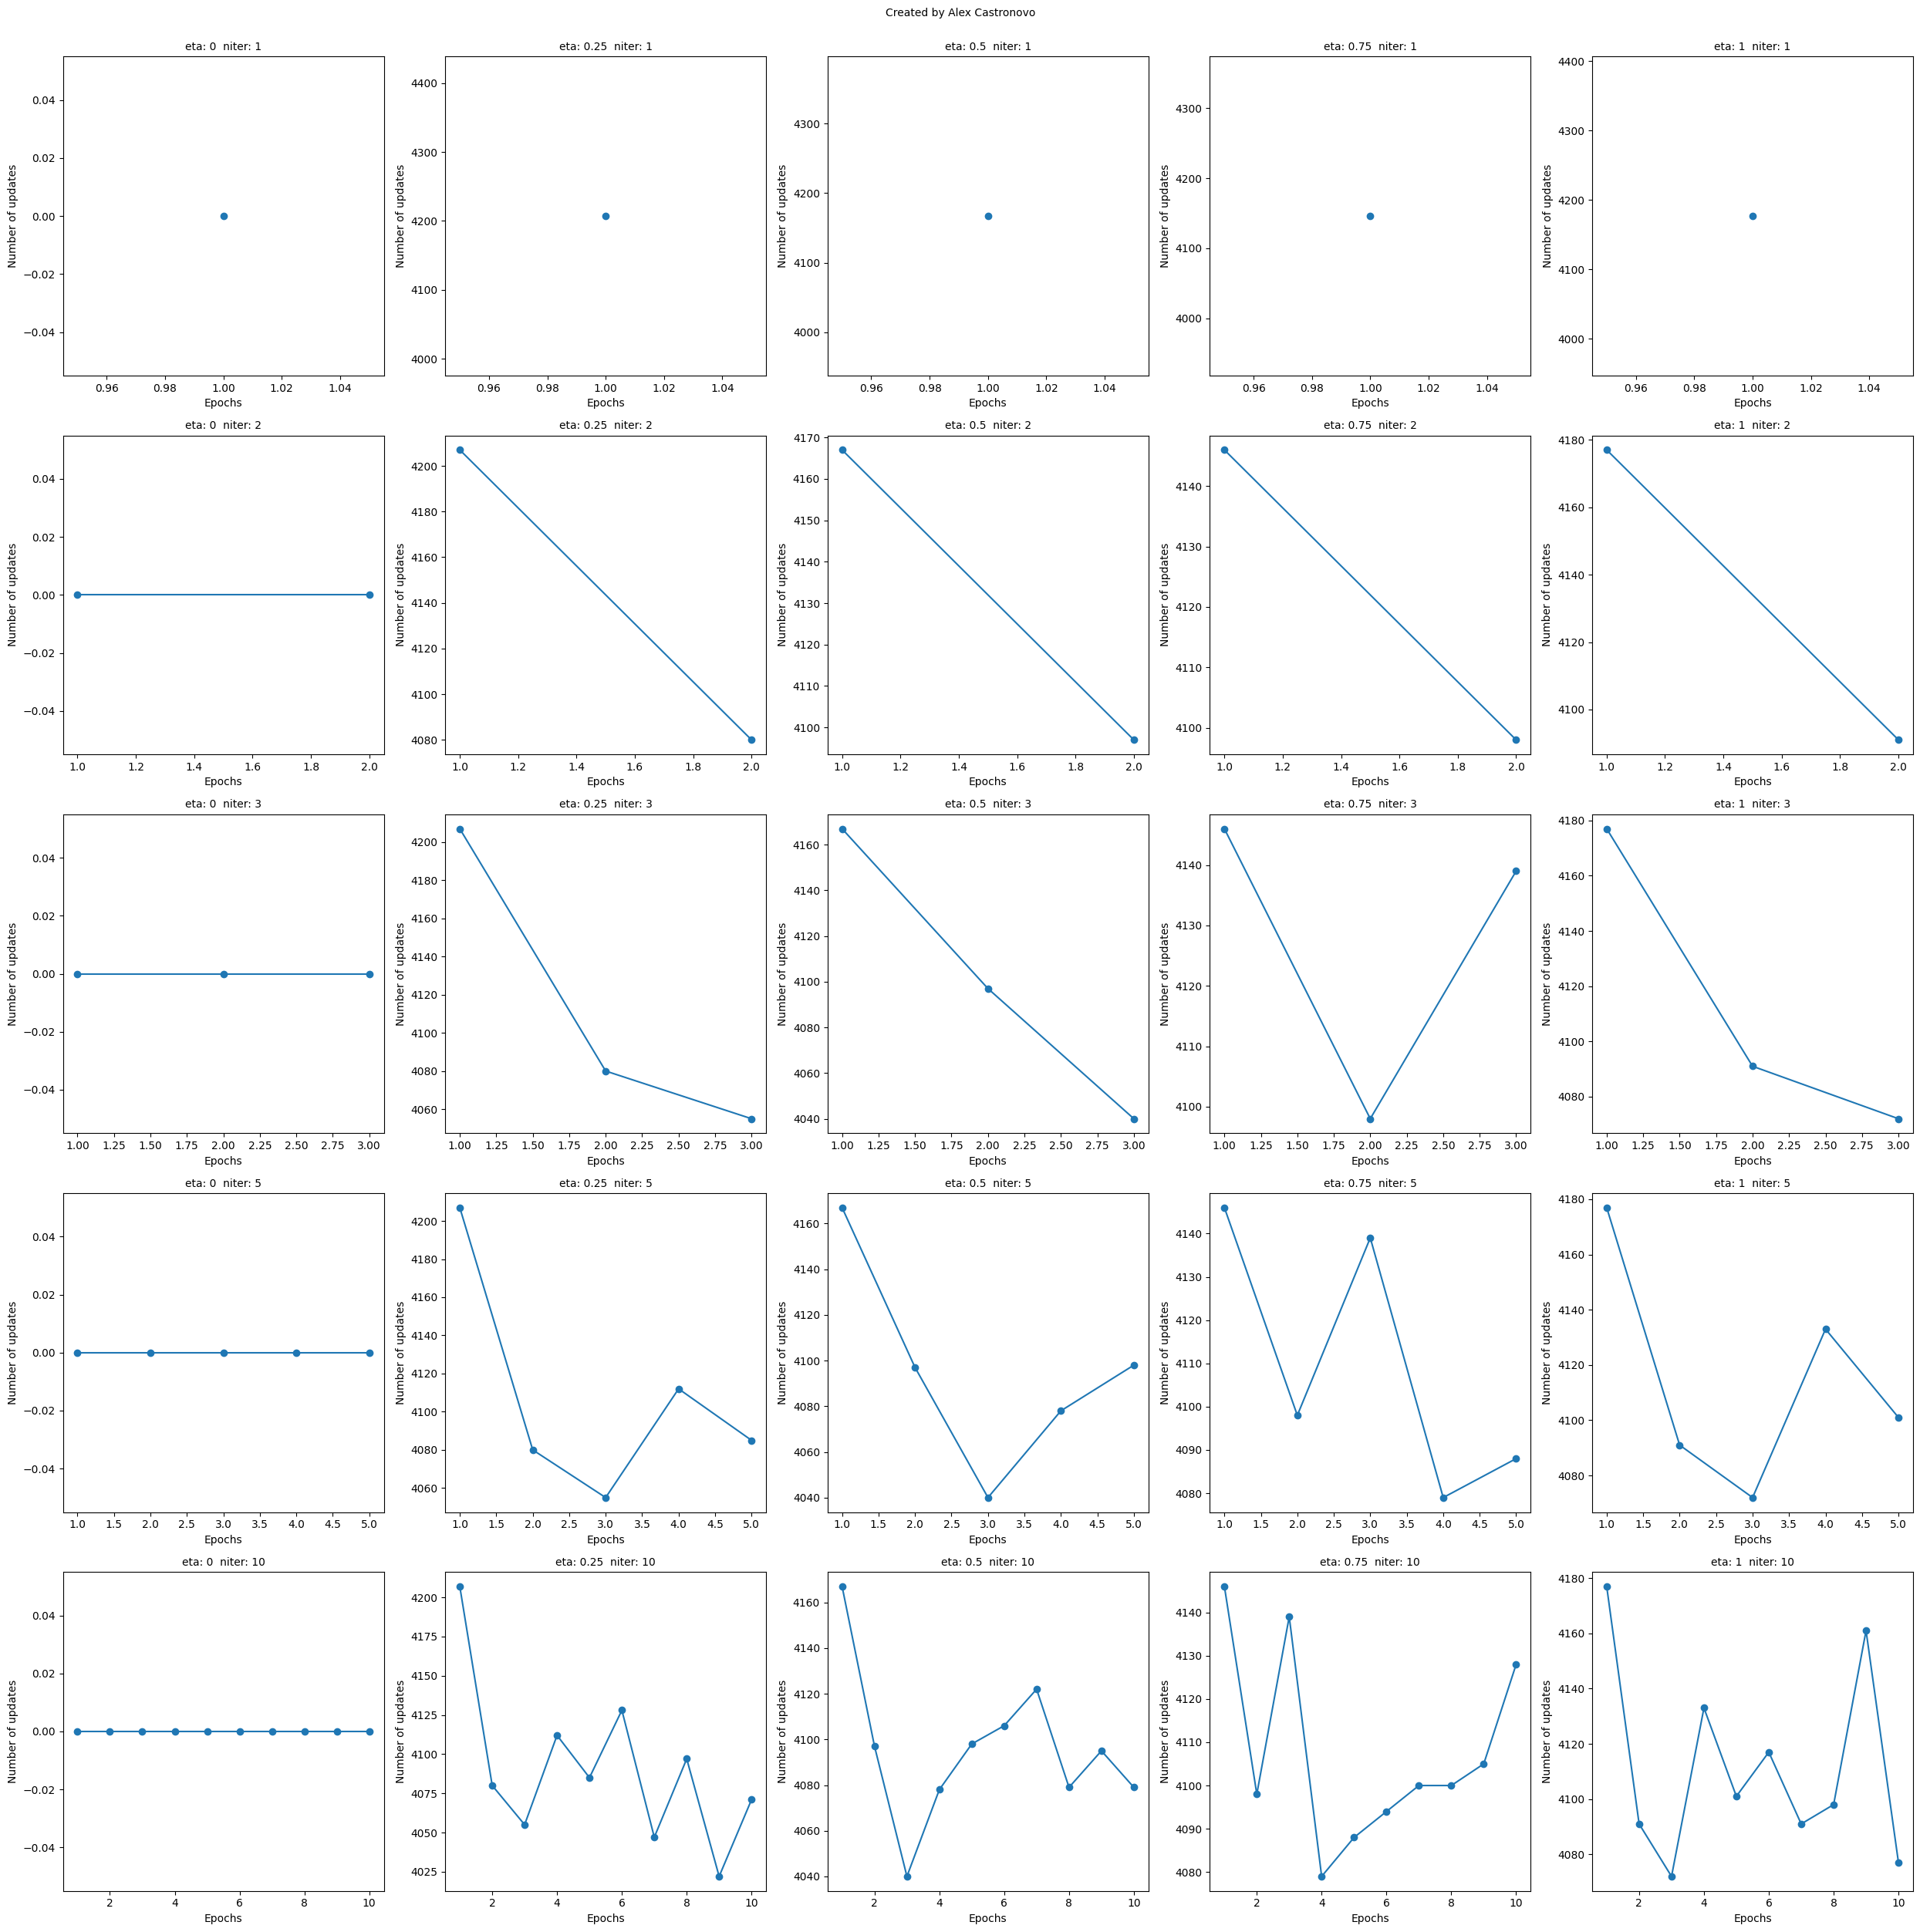

In [46]:
# Train Perceptron and find good value of eta and n_iter
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(25, 25))

list_eta = [0, 0.25, 0.5, 0.75, 1]
list_niter = [1, 2, 3, 5, 10]

fig.suptitle("Created by Alex Castronovo", fontsize=10, y=1)

for j, n_temp in enumerate(list_niter):

    for i, e_temp in enumerate(list_eta):
        ppn = Perceptron(n_iter=n_temp, eta= e_temp).fit(X_train, y_train)
        ax[j, i].plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
        ax[j, i].set_xlabel('Epochs', fontsize=10)
        ax[j, i].set_ylabel('Number of updates', fontsize=10)
        ax[j, i].set_title(f"eta: {e_temp}  niter: {n_temp}", fontsize=10)
    
plt.tight_layout()
plt.show()

In [47]:
# ### Testing the perceptron model
ppntest = Perceptron(eta=0.5, n_iter=3, random_state=1)
ppntest.fit(X_test, y_test)
y_pred = ppntest.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.83


In [48]:
class AdalineGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    losses_ : list
      Mean squared eror loss function values in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # Please note that the "activation" method has no effect
            # in the code since it is simply an identity function. We
            # could write `output = self.net_input(X)` directly instead.
            # The purpose of the activation is more conceptual, i.e.,  
            # in the case of logistic regression (as we will see later), 
            # we could change it to
            # a sigmoid function to implement a logistic regression classifier.
            output = self.activation(net_input)
            errors = (y - output)          
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

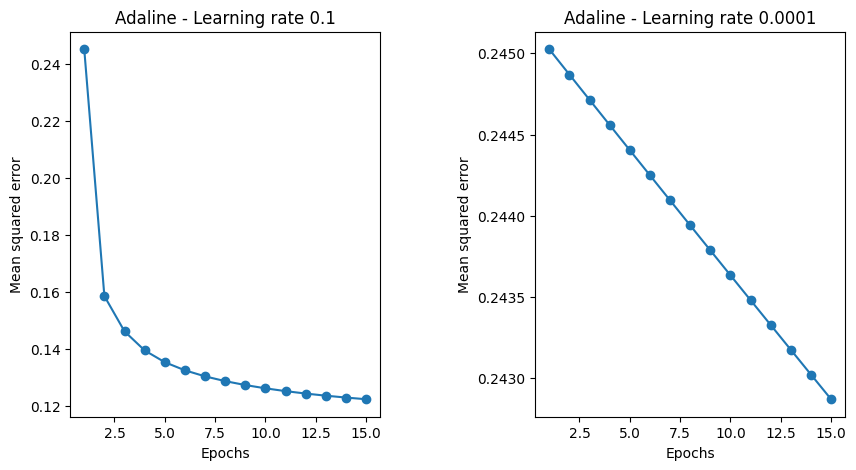

In [49]:
# Train adaptive linear neuron with AdalineGD with 2 different learning rates
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X_train, y_train)
ax[0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Mean squared error')
ax[0].set_title('Adaline - Learning rate 0.1')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X_train, y_train)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# Adjust the horizontal space between subplots
plt.subplots_adjust(wspace=0.5)

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

In [50]:
# predict on trained AdalineGD models
n_temp = 15
e_temp = 0.1
y_pred =ada1.predict(X_test)
print(f"Adaline accuracy with n_iter {n_temp} and eta {e_temp}: {accuracy_score(y_test, y_pred):.4f}")

n_temp = 15
e_temp = 0.0001
y_pred =ada2.predict(X_test)
print(f"Adaline accuracy with n_iter {n_temp} and eta {e_temp}: {accuracy_score(y_test, y_pred):.4f}")

Adaline accuracy with n_iter 15 and eta 0.1: 0.8198
Adaline accuracy with n_iter 15 and eta 0.0001: 0.7593


Adaline accuracy with n_iter 1 and eta 0.1: 0.7649
Adaline accuracy with n_iter 1 and eta 0.01: 0.7593
Adaline accuracy with n_iter 1 and eta 0.001: 0.7593
Adaline accuracy with n_iter 1 and eta 0.0001: 0.7593
Adaline accuracy with n_iter 1 and eta 1e-05: 0.7593
Adaline accuracy with n_iter 5 and eta 0.1: 0.7962
Adaline accuracy with n_iter 5 and eta 0.01: 0.7593
Adaline accuracy with n_iter 5 and eta 0.001: 0.7593
Adaline accuracy with n_iter 5 and eta 0.0001: 0.7593
Adaline accuracy with n_iter 5 and eta 1e-05: 0.7593
Adaline accuracy with n_iter 10 and eta 0.1: 0.8123
Adaline accuracy with n_iter 10 and eta 0.01: 0.7593
Adaline accuracy with n_iter 10 and eta 0.001: 0.7593
Adaline accuracy with n_iter 10 and eta 0.0001: 0.7593
Adaline accuracy with n_iter 10 and eta 1e-05: 0.7593
Adaline accuracy with n_iter 15 and eta 0.1: 0.8198
Adaline accuracy with n_iter 15 and eta 0.01: 0.7647
Adaline accuracy with n_iter 15 and eta 0.001: 0.7593
Adaline accuracy with n_iter 15 and eta 0.0001:

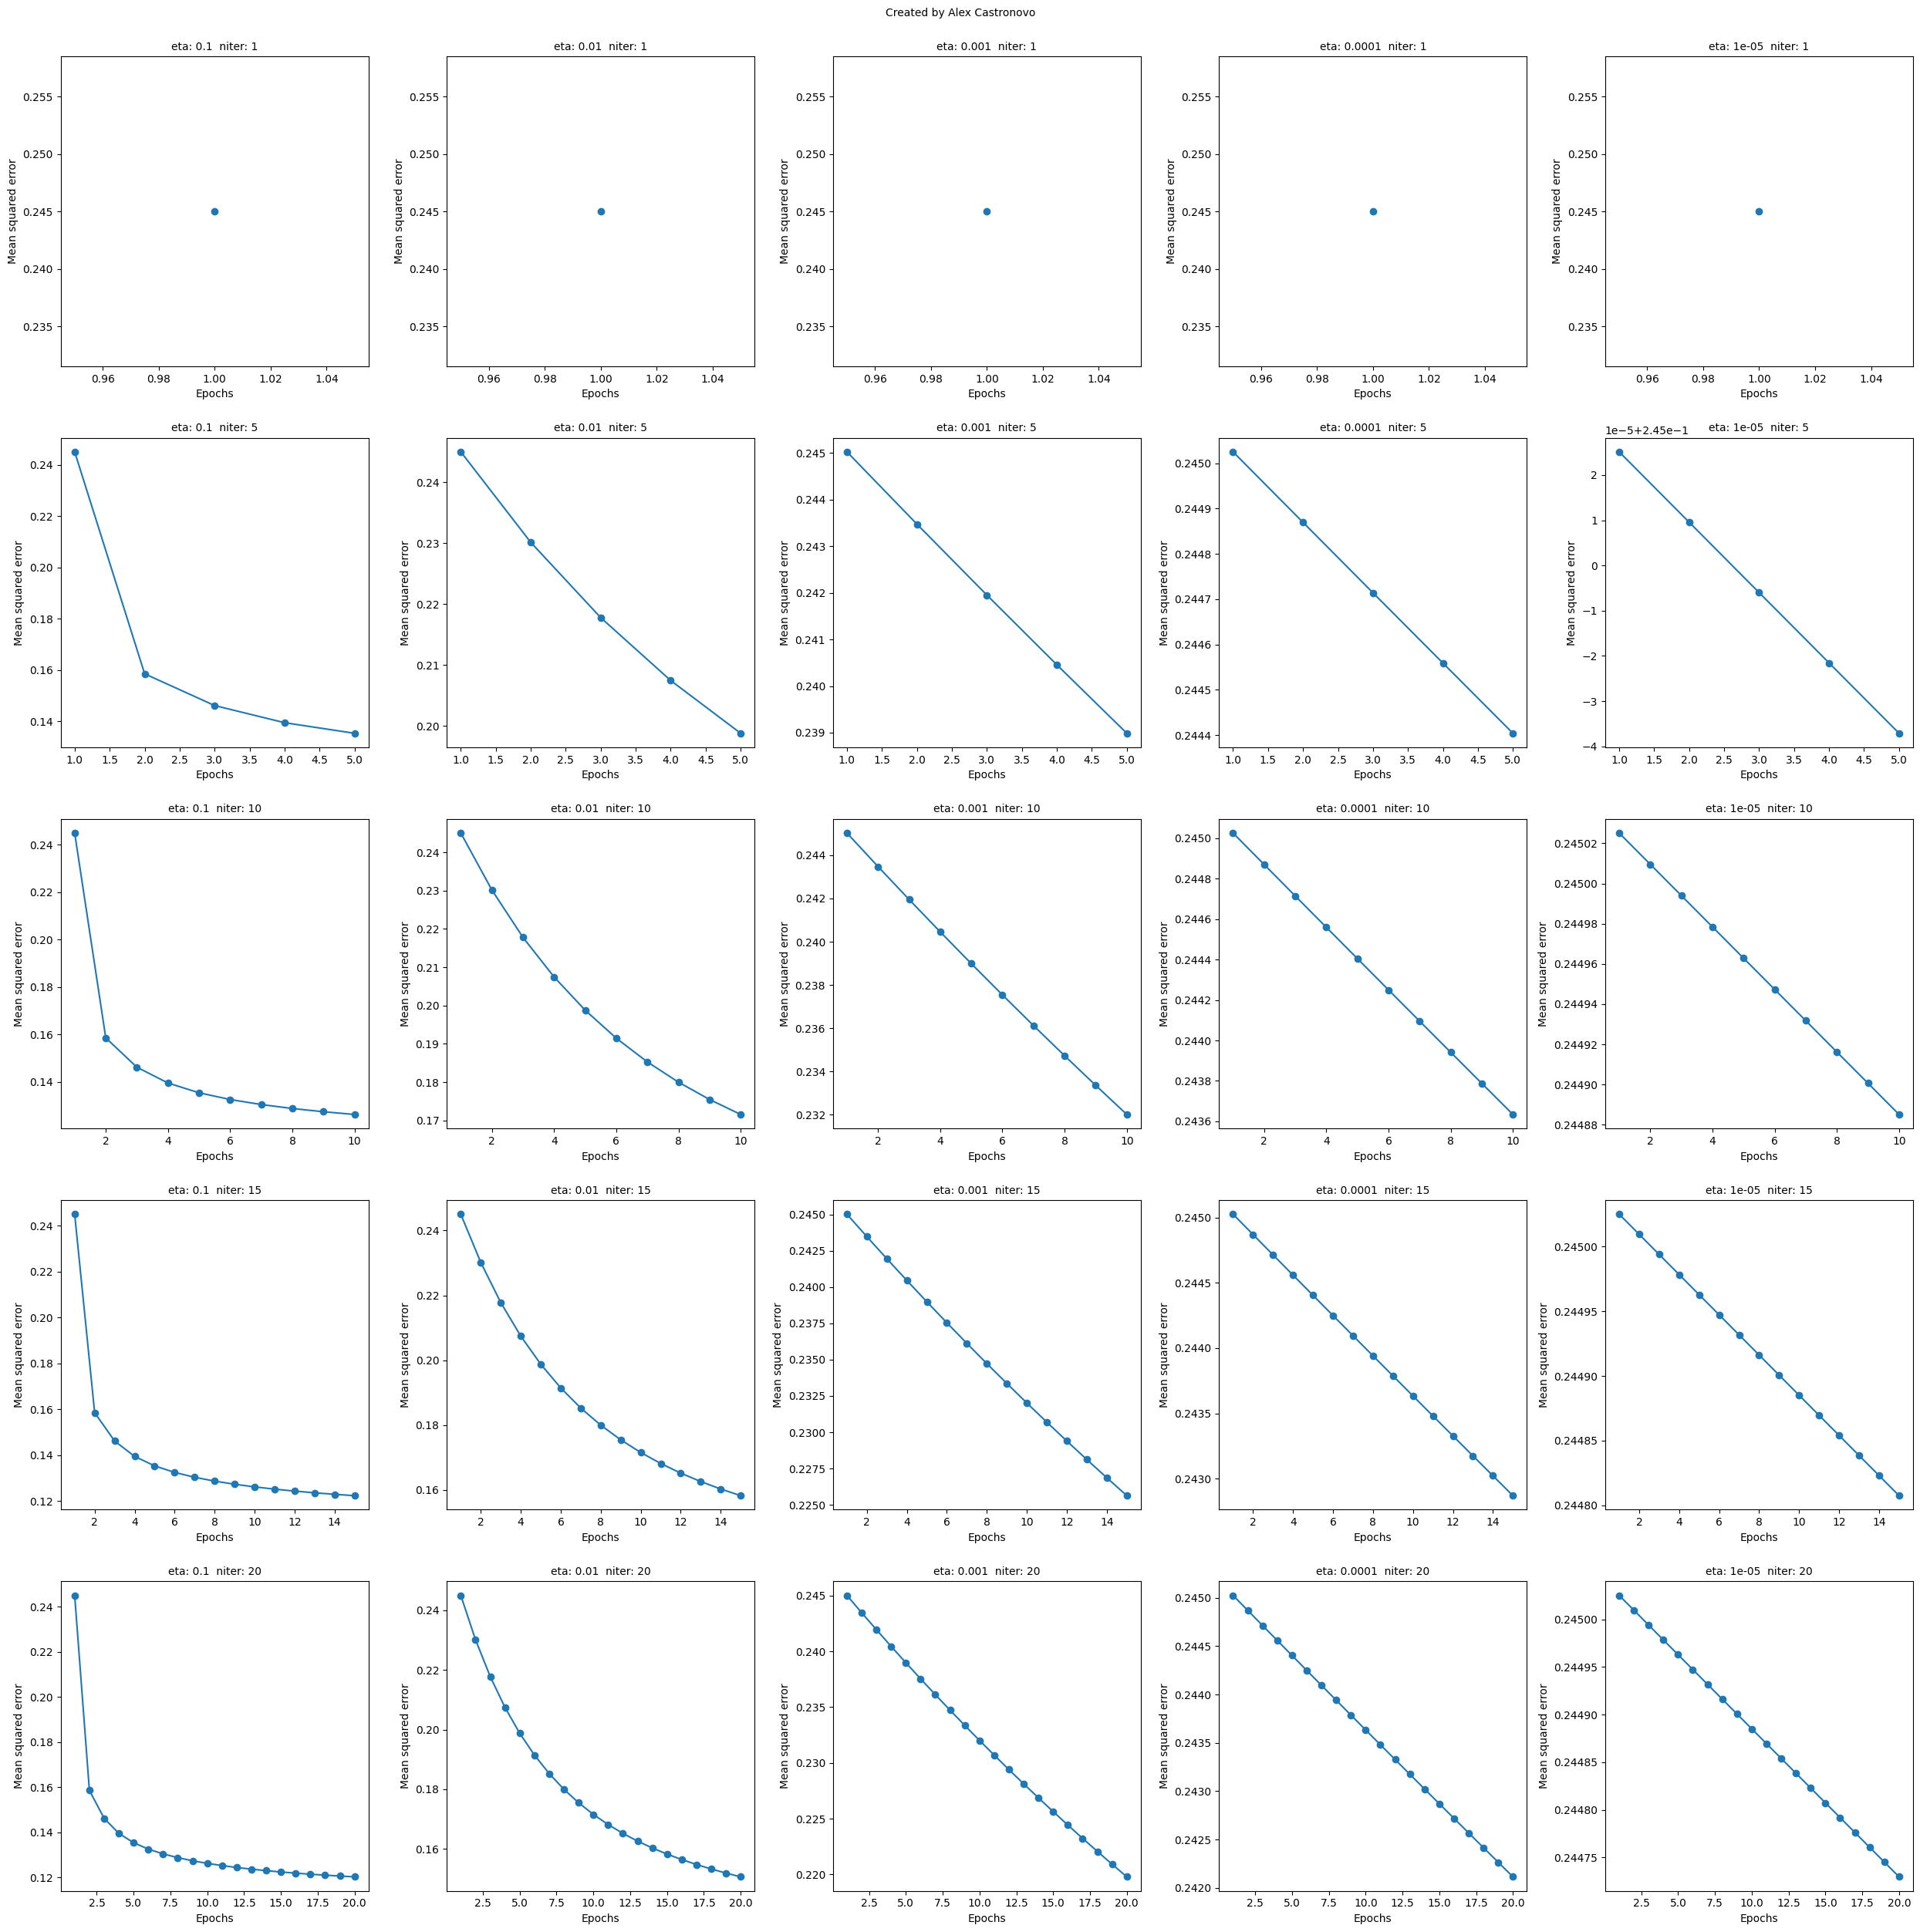

In [51]:
# looking at parameters eta and n_iter
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(25, 25))

list_eta = [.1, 0.01, 0.001, 0.0001, 0.00001]
list_niter = [1, 5, 10, 15, 20]

fig.suptitle("Created by Alex Castronovo", fontsize=10, y=1)

for j, n_temp in enumerate(list_niter):

    for i, e_temp in enumerate(list_eta):
        ada = AdalineGD(n_iter=n_temp, eta= e_temp).fit(X_train, y_train)
        ax[j, i].plot(range(1, len(ada.losses_) + 1), ada.losses_, marker='o')
        ax[j, i].set_xlabel('Epochs', fontsize=10)
        ax[j, i].set_ylabel('Mean squared error', fontsize=10)
        ax[j, i].set_title(f"eta: {e_temp}  niter: {n_temp}", fontsize=10)

        y_pred = ada.predict(X_test)
        print(f"Adaline accuracy with n_iter {n_temp} and eta {e_temp}: {accuracy_score(y_test, y_pred):.4f}")
    
plt.tight_layout()
plt.show()

In [52]:
class AdalineSGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    shuffle : bool (default: True)
      Shuffles training data every epoch if True to prevent cycles.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
        Bias unit after fitting.
    losses_ : list
      Mean squared error loss function value averaged over all
      training examples in each epoch.

        
    """
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state
        
    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]
    
    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True
        
    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_ += self.eta * 2.0 * xi * (error)
        self.b_ += self.eta * 2.0 * error
        loss = error**2
        return loss
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

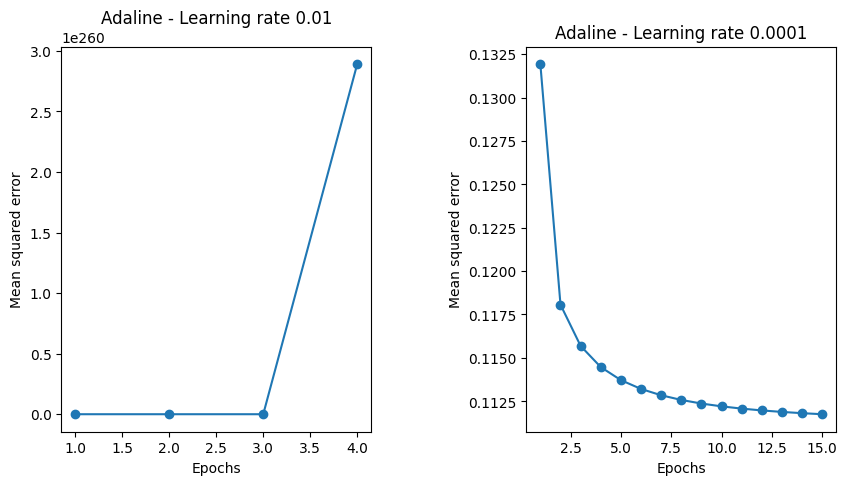

In [53]:
# Train adaptive linear neuron with AdalineSGD with 2 different learning rates.....without shuffling 
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ada1 = AdalineSGD(n_iter=15, eta=0.01, shuffle=False).fit(X_train, y_train)
ax[0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Mean squared error')
ax[0].set_title('Adaline - Learning rate 0.01')

ada2 = AdalineSGD(n_iter=15, eta=0.0001, shuffle=False).fit(X_train, y_train)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# Adjust the horizontal space between subplots
plt.subplots_adjust(wspace=0.5)

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

In [54]:
# predict on trained AdalineSGD models with shuffle FALSE
y_pred =ada1.predict(X_test)
print(f"Adaline accuracy with n_iter 15 and eta 0.1: {accuracy_score(y_test, y_pred):.4f}")

y_pred =ada2.predict(X_test)
print(f"Adaline accuracy with n_iter 15 and eta 0.0001: {accuracy_score(y_test, y_pred):.4f}")

Adaline accuracy with n_iter 15 and eta 0.1: 0.7593
Adaline accuracy with n_iter 15 and eta 0.0001: 0.8403


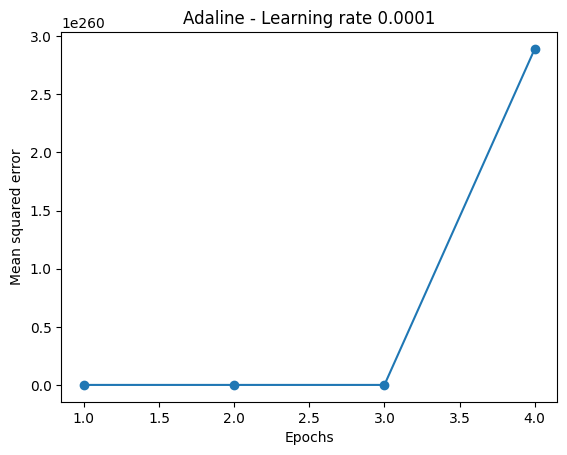

In [55]:
fig, ax = plt.subplots()
ada3 = AdalineSGD(n_iter=15, eta=0.0001, shuffle=True).fit(X_train, y_train)
ax.plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax.set_xlabel('Epochs')
ax.set_ylabel('Mean squared error')
ax.set_title('Adaline - Learning rate 0.0001')
plt.show()

In [56]:
# predict on trained AdalineSGD models with shuffle true
y_pred =ada3.predict(X_test)
print(f"Adaline accuracy with n_iter 15 and eta 0.0001: {accuracy_score(y_test, y_pred):.4f}")

Adaline accuracy with n_iter 15 and eta 0.0001: 0.8397


In [57]:
# Scikit-learn Perceptron
sk_ppn = SklearnPerceptron(eta0=0.1, max_iter=150, random_state=42)
sk_ppn.fit(X_train, y_train)
sk_y_pred_ppn = sk_ppn.predict(X_test)
print(f"Scikit-learn Perceptron accuracy: {accuracy_score(y_test, sk_y_pred_ppn):.4f}")

Scikit-learn Perceptron accuracy: 0.7541


In [58]:
# Scikit-learn Adaline (using SGDClassifier with 'log_loss' is closer, but 'perceptron' is available)
# For Adaline (which uses GD), SGDClassifier with 'hinge' loss is a good proxy, as it's a linear classifier with regularization
sk_ada = SGDClassifier(loss='perceptron', eta0=0.0001, learning_rate='constant', max_iter=15, random_state=42)
sk_ada.fit(X_train, y_train)
sk_y_pred_ada = sk_ada.predict(X_test)
print(f"Scikit-learn Adaline (SGDClassifier) accuracy: {accuracy_score(y_test, sk_y_pred_ada):.4f}")

Scikit-learn Adaline (SGDClassifier) accuracy: 0.8215


In [59]:
dfvalidation = pd.read_csv("/Users/lawsonlevin/ML/project1/data/project_validation_inputs.csv")

In [60]:
def prepare_validation_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()

    # Recover/ensure ID column from unnamed first column
    first_col = df.columns[0]
    if first_col == '' or 'Unnamed' in str(first_col):
        df = df.rename(columns={first_col: 'id'})

    # Normalize column names
    df.columns = (df.columns.str.strip()
                            .str.replace(' ', '_', regex=False)
                            .str.replace('-', '_', regex=False))

    # Missing indicators
    missing_indicators = ['?', 'unknown', 'Unknown', '', ' ', 'n/a', 'N/A', 'na', 'NA']
    df = df.replace(missing_indicators, np.nan)

    # Numeric coercions
    numeric_columns = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Feature engineering (must match training)
    if {'capital_gain', 'capital_loss'}.issubset(df.columns):
        df['capital_net'] = df['capital_gain'] - df['capital_loss']
        df['has_capital_gain'] = (df['capital_gain'] > 0).astype('Int64')
        df['has_capital_loss'] = (df['capital_loss'] > 0).astype('Int64')

    if 'age' in df.columns:
        df['age_group'] = pd.cut(
            df['age'],
            bins=[0, 25, 35, 45, 55, 65, 100],
            labels=['18_25', '26_35', '36_45', '46_55', '56_65', '65_plus']
        )

    if 'hours_per_week' in df.columns:
        df['work_hours_category'] = pd.cut(
            df['hours_per_week'],
            bins=[0, 30, 40, 50, 100],
            labels=['part_time', 'full_time', 'overtime', 'excessive']
        )

    if 'id' not in df.columns:
        raise KeyError("No 'id' column found. The first column must be the ID (unnamed) or named 'id'.")
    return df

def align_to_preprocessor_columns(df: pd.DataFrame, preprocessor) -> pd.DataFrame:
    if not hasattr(preprocessor, "feature_names_in_"):
        raise AttributeError("preprocessor.feature_names_in_ not found. Pass the FITTED preprocessor.")
    required_cols = list(preprocessor.feature_names_in_)
    for c in required_cols:
        if c not in df.columns:
            df[c] = np.nan
    return df[required_cols]

def coerce_pred_to_binary(y_pred, le_target=None):
    """
    Return 0/1 numpy array. If model already outputs 0/1, cast to int.
    If it outputs strings (e.g., '<=50K' / '>50K'), convert using le_target if provided,
    otherwise do a simple rule: contains '>' -> 1 else 0.
    """
    y_pred = np.asarray(y_pred)
    if np.issubdtype(y_pred.dtype, np.number):
        return y_pred.astype(int)
    if le_target is not None and hasattr(le_target, "classes_"):
        # Map classes to 0/1 using encoder learned at training
        return le_target.transform(y_pred).astype(int)
    # Fallback string rule
    return np.array([1 if (isinstance(v, str) and '>' in v) else 0 for v in y_pred], dtype=int)

In [61]:
# - ppntest  (trained Perceptron)
# - ada2     (trained Adaline)
# - preprocessor  (fitted ColumnTransformer from training)
# - le  (LabelEncoder from training, optional)



# Load and clean validation data
val = prepare_validation_data(dfvalidation) 

# 2) Align columns to what the fitted preprocessor expects and transform
X_val_raw = align_to_preprocessor_columns(val, prep)
X_val = prep.transform(X_val_raw)

# ------------------ Perceptron ------------------
y_val_ppn = ppntest.predict(X_val)
# Coerce to 0/1 robustly (handles numeric 0/1, {-1,1}, or string labels via le_target)
y_val_ppn_bin = coerce_pred_to_binary(y_val_ppn, le)

print("Perceptron prediction counts:", np.bincount(y_val_ppn_bin))
out_ppn = pd.DataFrame({"id": val["id"].to_numpy(), "prediction": y_val_ppn_bin.astype(int)})
out_ppn.to_csv("Group_24_Perceptron_PredictedOutputs.csv", index=False)
print(f"Saved Group_24_Perceptron_PredictedOutputs.csv ({len(out_ppn)} rows)")

# ------------------ Adaline ------------------
y_val_ada = ada2.predict(X_val)

# If Adaline outputs continuous values, threshold at 0; if already 0/1, this preserves them
if np.issubdtype(np.asarray(y_val_ada).dtype, np.number) and not set(np.unique(y_val_ada)).issubset({0,1}):
    y_val_ada_bin = (np.asarray(y_val_ada).ravel() >= 0).astype(int)
else:
    y_val_ada_bin = coerce_pred_to_binary(y_val_ada, le)

print("Adaline prediction counts:", np.bincount(y_val_ada_bin))
out_ada = pd.DataFrame({"id": val["id"].to_numpy(), "prediction": y_val_ada_bin.astype(int)})
out_ada.to_csv("Group_24_Adaline_PredictedOutputs.csv", index=False)
print(f"Saved Group_24_Adaline_PredictedOutputs.csv ({len(out_ada)} rows)")

Perceptron prediction counts: [4949 1564]
Saved Group_24_Perceptron_PredictedOutputs.csv (6513 rows)
Adaline prediction counts: [5404 1109]
Saved Group_24_Adaline_PredictedOutputs.csv (6513 rows)


In [62]:
def plot_confusion_matrix(cm, y_true):
    """
    Plots the confusion matrix using a heatmap.

    Args:
        cm (np.ndarray): The confusion matrix.
        y_true (np.ndarray): The true labels for the test data.
    """
    # Create the plot using pure matplotlib
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Use imshow to create the heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the unique class names
           xticklabels=np.unique(y_true), yticklabels=np.unique(y_true),
           title='Confusion Matrix',
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.show()

In [63]:
def plot_best_svm_decision_boundary(grid_search, X, y):
    """
    Plots the decision boundaries for the best SVM model found by GridSearchCV.

    Args:
        grid_search (GridSearchCV): The fitted GridSearchCV object.
        X (pd.DataFrame): The input features (must be a DataFrame for feature names).
        y (pd.Series or np.ndarray): The target labels.
    """
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_kernel = best_params.get('kernel', 'linear') # Default to linear if not found

    # Standardize the y input and encode if necessary
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("If 'y' is a DataFrame, it must contain a single column.")
        y_series = y.iloc[:, 0]
    elif isinstance(y, (pd.Series, np.ndarray)):
        y_series = pd.Series(y).ravel()
    else:
        raise TypeError("y must be a pandas DataFrame, Series, or a NumPy array.")
    
    if y_series.dtype == 'object':
        print("Encoding string labels to numerical format...")
        le = LabelEncoder()
        y_encoded = le.fit_transform(y_series)
    else:
        y_encoded = y_series.values

    n_features = X.shape[1]
    if n_features < 2:
        raise ValueError("This function requires at least 2 features for plotting combinations.")

    feature_pairs = list(combinations(range(n_features), 2))
    n_pairs = len(feature_pairs)
    
    fig, axes = plt.subplots(1, n_pairs, figsize=(n_pairs * 6, 6), constrained_layout=True)

    # Ensure axes is an array even for a single subplot
    if n_pairs == 1:
        axes = [axes]

    for j, (f1_idx, f2_idx) in enumerate(feature_pairs):
        ax = axes[j]
        
        # Select the two features for the current plot
        X_pair = X.iloc[:, [f1_idx, f2_idx]]
        f1_name = X.columns[f1_idx]
        f2_name = X.columns[f2_idx]

        # Use the best model from GridSearchCV
        model = best_model
        
        # Since the best model was trained on the full dataset, we'll retrain
        # a new instance of it on just the two features for plotting purposes.
        # This is the most reliable way to ensure the decision boundary is correct.
        plot_model = SVC(
            kernel=best_params.get('kernel'),
            C=best_params.get('C'),
            gamma=best_params.get('gamma')
        )
        if best_kernel == 'poly':
            plot_model.degree = best_params.get('degree', 3) # Handle poly degree separately
        plot_model.fit(X_pair.values, y_encoded)
        
        # Plot the data points
        ax.scatter(X_pair.iloc[:, 0], X_pair.iloc[:, 1], c=y_encoded, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

        # Create and plot the decision boundary
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 500),
                             np.linspace(ylim[0], ylim[1], 500))
        Z = plot_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        
        # Highlight the support vectors
        ax.scatter(plot_model.support_vectors_[:, 0], plot_model.support_vectors_[:, 1], s=100,
                   linewidth=1, facecolors='none', edgecolors='k')
        
        # Set titles and labels
        ax.set_title(f"Best Model ({best_kernel.capitalize()} kernel)\n({f1_name} vs {f2_name})")
        ax.set_xlabel(f1_name)
        ax.set_ylabel(f2_name)
        ax.set_aspect('equal', adjustable='box')

    plt.suptitle(f"GridSearchCV Best Model Decision Boundaries\nBest Params: {best_params}", y=1.05)
    plt.show()

# Part 3

## a) Train Logistic Regression model using scikit-learn (No GridSearch)

In [64]:
# Initialize the model with default parameters.
# For multi-class problems, LogisticRegression uses a one-vs-rest strategy by default.
# The 'solver' is set to 'lbfgs' as it's a good default for multi-class problems.
lr_model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=200)
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


## a) Train Logistic Regression model using scikit-learn (With GridSearch)

In [65]:
# We use GridSearchCV to find the best hyperparameters for the model.
# Cross-validation (CV) helps to get a more robust estimate of model performance
# and prevents overfitting to a single train-test split.

# Define the parameter grid to search over.
# np.logspace(-4,4,20) tells GridSearchCV to test 20 values for C evenly spaced on logarithmic scale from 10^-4 to 10^4
param_grid = {
    'C': np.logspace(-4, 4, 20),  # Inverse of regularization strength
}

# Initialize GridSearchCV with a 5-fold cross-validation strategy.
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(solver='lbfgs', random_state=42, max_iter=200),
    param_grid=param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='accuracy',       # Metric to optimize for
    n_jobs=-1,                # Use all available CPU cores
    verbose=1                 # Print progress
)

print("Starting hyperparameter search. This may take a moment...")
grid_search_lr.fit(X_train, y_train.ravel())

Starting hyperparameter search. This may take a moment...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,{'C': array([1.0000...00000000e+04])}
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


## a) Train Support Vector Machine (SVM) models using scikit-learn (No GridSearch)

In [66]:
# Train and evaluate three initial SVM kernels
svm_linear = SVC(kernel='linear', C=1, random_state=42).fit(X_train, y_train.ravel())
svm_rbf    = SVC(kernel='rbf',    C=1, random_state=42).fit(X_train, y_train.ravel())
svm_poly   = SVC(kernel='poly',   C=1, random_state=42).fit(X_train, y_train.ravel())

## a) Train Support Vector Machine (SVM) models using scikit-learn (With GridSearch)

In [67]:
# We use GridSearchCV to find the best hyperparameters for the model.
# Cross-validation (CV) helps to get a more robust estimate of model performance
# and prevents overfitting to a single train-test split.

# Define the parameter grid to search over.
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}


# Initialize GridSearchCV with a 5-fold cross-validation strategy.
svm_grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='accuracy',       # Metric to optimize for
    n_jobs=-1,                # Use all available CPU cores
    verbose=1                 # Print progress
)

print("Starting hyperparameter search. This may take a moment...")
svm_grid_search.fit(X_train, y_train)

Starting hyperparameter search. This may take a moment...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


## b) Find the accuracy of your best models from both algorithms

### I) Find the most accurate Logistic Regression model


=== Baseline Logistic Regression ===
Test accuracy: 0.8520
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      3956
           1       0.74      0.60      0.66      1254

    accuracy                           0.85      5210
   macro avg       0.81      0.77      0.78      5210
weighted avg       0.85      0.85      0.85      5210

Confusion matrix:
 [[3690  266]
 [ 505  749]]

=== Tuned Logistic Regression (GridSearchCV) ===
Best params: {'C': np.float64(545.5594781168514)}
Cross-Validation accuracy (mean): 0.8590
Test accuracy:       0.8493
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      3956
           1       0.73      0.59      0.65      1254

    accuracy                           0.85      5210
   macro avg       0.80      0.76      0.78      5210
weighted avg       0.84      0.85      0.84      5210

Confusion matrix:
 [[3681  275]
 [ 510  744]]

>>> Selected best LR mod

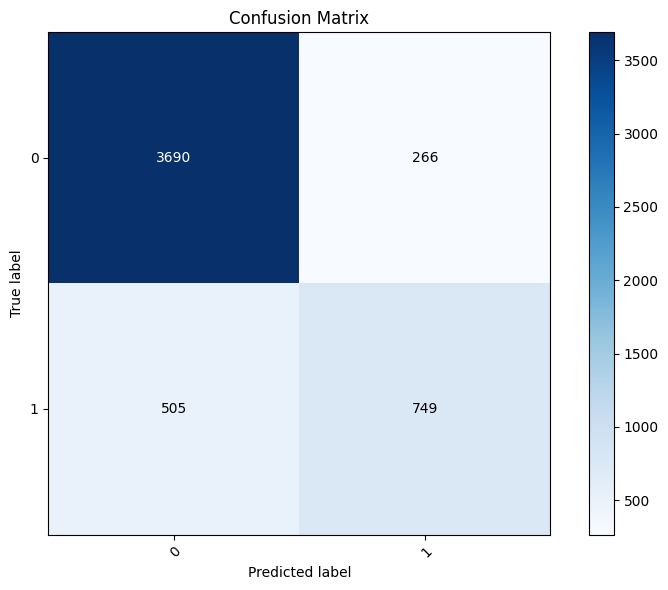

In [68]:
# Baseline Logistic Regression Model
y_pred_base = lr_model.predict(X_test)
accuracy_base = accuracy_score(y_test, y_pred_base)
print("\n=== Baseline Logistic Regression ===")
print(f"Test accuracy: {accuracy_base:.4f}")
print(classification_report(y_test, y_pred_base))
cm_base = confusion_matrix(y_test, y_pred_base)
print("Confusion matrix:\n", cm_base)

# Tuned Logistic Regression Model from GridSearch
gs_lr = grid_search_lr.best_estimator_
y_pred_tuned = grid_search_lr.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print("\n=== Tuned Logistic Regression (GridSearchCV) ===")
print("Best params:", grid_search_lr.best_params_)
print(f"Cross-Validation accuracy (mean): {grid_search_lr.best_score_:.4f}")
print(f"Test accuracy:       {accuracy_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Confusion matrix:\n", cm_tuned)

# Choose the better LR model
if accuracy_tuned >= accuracy_base:
    best_lr_algorithm = gs_lr
    best_lr_name = "Tuned (GridSearchCV)"
    best_lr_cm = cm_tuned
else:
    best_lr_algorithm = lr_model
    best_lr_name = "Baseline"
    best_lr_cm = cm_base

print(f"\n>>> Selected best LR model: {best_lr_name} (accuracy={max(accuracy_base, accuracy_tuned):.4f})")

# Plot confusion matrix for the selected best LR
try:
    plot_confusion_matrix(best_lr_cm, y_test)
except Exception as e:
    print("Confusion matrix plot skipped:", e)

### II) Find the most accurate Support Vector Machines (SVM) model


================  Linear (C=1)  ================

Accuracy: 0.8491

Confusion Matrix:
[[3703  253]
 [ 533  721]]

================  RBF (C=1)  ================

Accuracy: 0.8491

Confusion Matrix:
[[3723  233]
 [ 553  701]]

================  Poly (C=1)  ================

Accuracy: 0.8482

Confusion Matrix:
[[3727  229]
 [ 562  692]]

================  GridSearch Best  ================

Accuracy: 0.8491

Confusion Matrix:
[[3703  253]
 [ 533  721]]

================  SUMMARY  ================
Linear (C=1)       -> accuracy: 0.8491
RBF (C=1)          -> accuracy: 0.8491
Poly (C=1)         -> accuracy: 0.8482
GridSearch Best    -> accuracy: 0.8491

>>> Selected best SVM model: Linear (C=1) (accuracy=0.8491)

Plotting confusion matrix for best SVM: Linear (C=1)


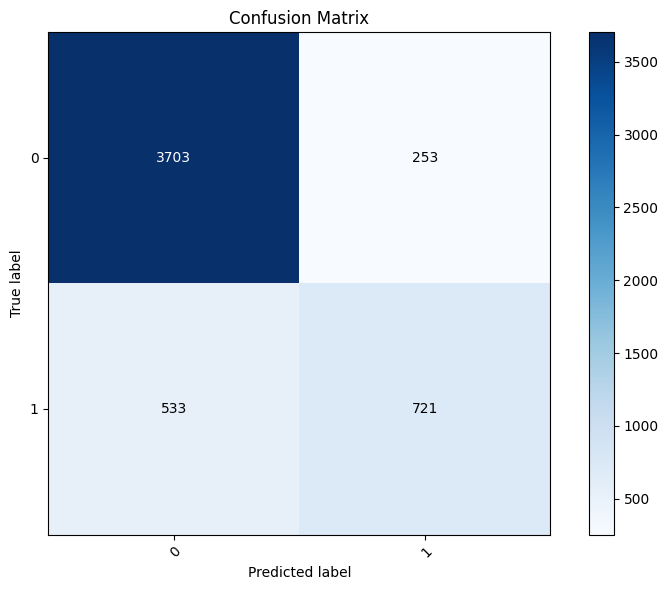

In [69]:
# Collect all four models
svm_all = {
    "Linear (C=1)": svm_linear,
    "RBF (C=1)":    svm_rbf,
    "Poly (C=1)":   svm_poly,
    "GridSearch Best": svm_grid_search.best_estimator_
}

svm_results = {}

for name, clf in svm_all.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)

    print(f"\n================  {name}  ================\n")
    print(f"Accuracy: {acc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    svm_results[name] = {"model": clf, "accuracy": acc, "cm": cm}

# Summary and selecting best model
best_name = max(svm_results, key=lambda k: svm_results[k]["accuracy"])
best_svm_algorithm = svm_results[best_name]["model"]

print("\n================  SUMMARY  ================")
for name, res in svm_results.items():
    print(f"{name:<18} -> accuracy: {res['accuracy']:.4f}")

print(f"\n>>> Selected best SVM model: {best_name} "
      f"(accuracy={svm_results[best_name]['accuracy']:.4f})")

# If GridSearch won, show its best params
if "GridSearch Best" == best_name:
    print("Best params from GridSearch:", svm_grid_search.best_params_)

# Plot confusion matrix for the best SVM model ---
best_cm = svm_results[best_name]["cm"]

print(f"\nPlotting confusion matrix for best SVM: {best_name}")
plot_confusion_matrix(best_cm, y_test)

## c) Use best performing models to predict outputs for project_validation_inputs

### I) Logistic Regression Predictions

In [70]:
model_lr = best_lr_algorithm

validation_data = prepare_validation_data(dfvalidation)

X_validation_raw = align_to_preprocessor_columns(validation_data, prep)
X_validation = prep.transform(X_validation_raw)

y_lr = model_lr.predict(X_validation)
y_lr_bin = coerce_pred_to_binary(y_lr, le)

output_lr = pd.DataFrame({
    "id": validation_data["id"].to_numpy(),
    "prediction": y_lr_bin
})

output_lr.to_csv("Group_24_LogisticRegression_PredictedOutputs.csv", index=False)
print(f"Saved Group_24_LogisticRegression_PredictedOutputs.csv ({len(output_lr)} rows)")

Saved Group_24_LogisticRegression_PredictedOutputs.csv (6513 rows)


### II) Support Vector Machines (SVM) Predictions

In [71]:
model_svm = best_svm_algorithm

validation_data = prepare_validation_data(dfvalidation)

X_validation_raw = align_to_preprocessor_columns(validation_data, prep)
X_validation = prep.transform(X_validation_raw)

y_svm = model_svm.predict(X_validation)
y_svm_bin = coerce_pred_to_binary(y_svm, le)

output_svm = pd.DataFrame({
    "id": validation_data["id"].to_numpy(),
    "prediction": y_svm_bin
})

output_svm.to_csv("Group_24_SVM_PredictedOutputs.csv", index=False)
print(f"Group_24_SVM_PredictedOutputs.csv ({len(output_svm)} rows)")

Group_24_SVM_PredictedOutputs.csv (6513 rows)


## d) Select 2 features and visualize the decesion boundaries

Explained variance ratio [PC1, PC2]: [0.17723219 0.11741364]
Total variance explained by 2 PCs: 0.294645831179511


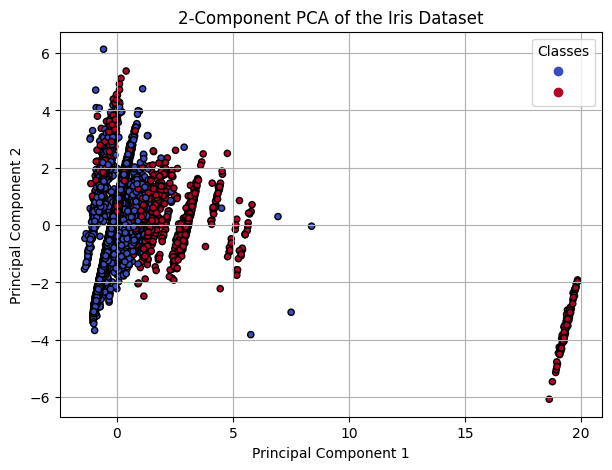

In [72]:
# Reduce to 2 principal components (fit on training set only)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

# Wrap as DataFrames with clean column names
pca_df = pd.DataFrame(data = X_train_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['target'] = y_train.ravel()


# Report variance explained by PC1 & PC2
print("Explained variance ratio [PC1, PC2]:", pca.explained_variance_ratio_)
print("Total variance explained by 2 PCs:", pca.explained_variance_ratio_.sum())

# Visualize the results
plt.figure(figsize=(7,5))
scatter = plt.scatter(pca_df['Principal Component 1'], pca_df['Principal Component 2'],
                      c=pca_df['target'], cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2-Component PCA of the Iris Dataset')
plt.legend(handles=scatter.legend_elements()[0], title="Classes")
plt.grid(True)
plt.show()

In [73]:
# Get feature names from the preprocessor
num_features = prep.transformers_[0][2]
cat_features = prep.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(prep.transformers_[1][2])
all_feature_names = list(num_features) + list(cat_features)

# Now build the loadings DataFrame
loadings = pd.DataFrame(
    pca.components_,
    columns=all_feature_names,
    index=['PC1', 'PC2']
)

print("Principal Component Loadings:")
print(loadings.T.sort_values(by='PC1', key=lambda x: abs(x), ascending=False).head(10))
print(loadings.T.sort_values(by='PC2', key=lambda x: abs(x), ascending=False).head(10))

Principal Component Loadings:
                                        PC1       PC2
capital_net                        0.678147 -0.167537
capital_gain                       0.677409 -0.148809
age                                0.166952  0.607303
hours_per_week                     0.136106  0.466408
has_capital_gain_1                 0.097440 -0.002758
marital_status_Married-civ-spouse  0.064306  0.209042
marital_status_Never-married      -0.063743 -0.240123
capital_loss                      -0.053811  0.334663
relationship_Own-child            -0.041307 -0.155411
work_hours_category_part_time     -0.034745 -0.136743
                                        PC1       PC2
age                                0.166952  0.607303
hours_per_week                     0.136106  0.466408
capital_loss                      -0.053811  0.334663
marital_status_Never-married      -0.063743 -0.240123
marital_status_Married-civ-spouse  0.064306  0.209042
fnlwgt                            -0.030450 -0.17844

X2_scaled shape: (26048, 2)
y2_df shape: (26048, 1)
Encoding string labels to numerical format...


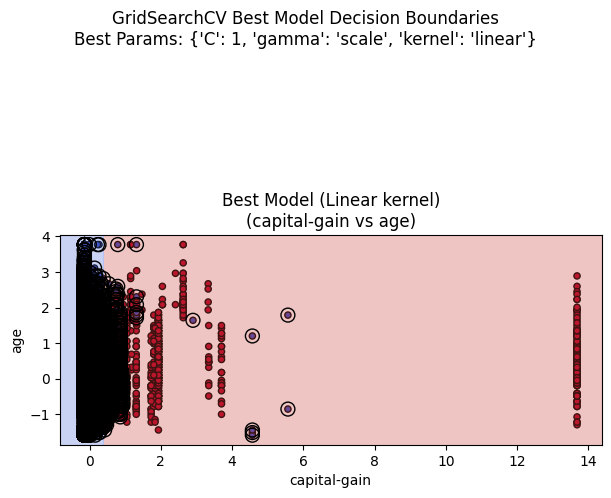

In [74]:
feat_pair = ['capital-gain', 'age']

# Build a single masked view so X and y have identical rows
cols_needed = feat_pair + ['income']
missing = [c for c in cols_needed if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns in df: {missing}\nAvailable: {list(df.columns)}")

mask = df[cols_needed].notnull().all(axis=1)
df_xy = df.loc[mask, cols_needed].copy()

# Split into X and y, and scale X 
X2 = df_xy[feat_pair]
y2_df = df_xy[['income']].rename(columns={'income': 'target'})  # one-column DataFrame

scaler = StandardScaler()
X2_scaled = pd.DataFrame(
    scaler.fit_transform(X2),
    columns=feat_pair,
    index=X2.index
)

print("X2_scaled shape:", X2_scaled.shape)
print("y2_df shape:", y2_df.shape)
assert len(X2_scaled) == len(y2_df) and len(y2_df) > 0, "X and y lengths must match and be > 0."

# Plot decision boundary for BEST SVM from GridSearchCV
plot_best_svm_decision_boundary(svm_grid_search, X2_scaled, y2_df)